# Ejercicio 6 - Pŕactica 4

Utilizando el dataset `partos2022.txt`, el cual contiene información sobre los partos atendidos en el 2022 en el Hospital Roque Sáenz Peña (HRSP) y la Maternidad Martin (MR), efectores municipales de la ciudad:

1. Indique los meses en los que se registró la mayor y la menor cantidad de partos atendidos. ¿Qué porcentajes del total de partos atendidos en el año representan?

2. Represente gráficamente la distribución del número de partos atendidos en el 2022 según el efector. ¿Qué puede decir acerca de la institución en la que tuvieron lugar los partos?

3. Realice un gráfico que permita comparar la distribución del peso de los recién nacidos entre las distintas categorías de la edad gestacional. ¿Qué observa?

4. Realice una descripción general de las variables rango etario de la madre (`rango_edad_mama`) y tipo de parto (`terminacion_parto`) que incluya: tipo de variables, valores que toman, distribución de cada una en la muestra y presencia de datos faltantes.

5. Recategorice la variable `rango_edad_mama` de la siguiente manera: 10-19 años, 20-29 años, 30-39 años y 40 años o más.

6. Recategorice la variable `terminacion_parto` de forma tal que la categoría Fórceps se encuentre comprendida dentro de Otros.

7. Construya un gráfico de barras paralelas que muestre la distribución general del tipo de parto (Cesárea/Normal/Otros) según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados sobre el total general de partos atendidos para los que se cuenta con información sobre la edad de la madre (`n = 4577`).

8. Construya un gráfico de barras paralelas que muestre la distribución del tipo de parto según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados sobre el total de partos atendidos para cada uno de estos grupos etarios.

---

Para tener de referencia, en la siguiente figura se muestran ambos gráficos terminados. Para su construcción se utilizó, en ambos casos, la función `plot.barh()` de Pandas, previa generación de las respectivas tablas de doble entrada, y los colores de las barras pertenecen a la paleta deep.

 ![Imagen 1](../img/f6b5096a92bb84d0c301ec99cc85259c3e5ab71185e1c1964b5709a05f38d72f.png)

 ---

9. Compare los gráficos realizados en el ítem anterior. ¿Qué tipo de información brinda cada uno?

10. PARA PENSAR: ¿Cuál de los gráficos anteriores le permite analizar si la edad de la madre influye en la probabilidad de recurrir a una cesárea como método de parto? ¿Qué observa?

## Cargamos el data frame

In [11]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [15]:
df = pd.read_csv("../datasets/partos2022.txt", sep='\t', encoding="latin1")
df.head()

,año,mes,efector,idParto,idMama,rango_edad_mama,n_hijo,lugar_parto,terminacion_parto,edad_gestacional,peso_bb,sexo,nacimiento
0,2022,8,HRSP,1,951,35 a 39 años,1,Quirófano,Cesárea,32 a 37 sem,2980,M,Vivo
1,2022,1,HRSP,2,3437,25 a 29 años,1,Quirófano,Cesárea,38 a 41 sem,4215,F,Vivo
2,2022,1,HRSP,3,3411,20 a 24 años,1,Sala de partos,Normal,38 a 41 sem,3920,M,Vivo
3,2022,1,HRSP,4,528,25 a 29 años,1,Sala de partos,Normal,38 a 41 sem,3950,M,Vivo
4,2022,1,HRSP,5,2030,30 a 34 años,1,Sala de partos,Normal,38 a 41 sem,2650,M,Vivo


In [50]:
df.info()

# Vemos que sólo hay valores nulos en la variable rango_edad_mama

<class 'pandas.DataFrame'>
RangeIndex: 4597 entries, 0 to 4596
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   año                4597 non-null   int64
 1   mes                4597 non-null   int64
 2   efector            4597 non-null   str  
 3   idParto            4597 non-null   int64
 4   idMama             4597 non-null   int64
 5   rango_edad_mama    4577 non-null   str  
 6   n_hijo             4597 non-null   int64
 7   lugar_parto        4597 non-null   str  
 8   terminacion_parto  4597 non-null   str  
 9   edad_gestacional   4597 non-null   str  
 10  peso_bb            4597 non-null   int64
 11  sexo               4597 non-null   str  
 12  nacimiento         4597 non-null   str  
dtypes: int64(6), str(7)
memory usage: 467.0 KB


In [17]:
df['año'].unique()
# Tienen todos el mismo año. Podemos borrar esa columna.

array([2022])

## Item 1

Indique los meses en los que se registró la mayor y la menor cantidad de partos atendidos. ¿Qué porcentajes del total de partos atendidos en el año representan?

In [31]:
df['mes'].value_counts(normalize=True).round(2).sort_index()

mes
1     0.09
2     0.09
3     0.10
4     0.11
5     0.07
6     0.06
7     0.09
8     0.09
9     0.07
10    0.08
11    0.08
12    0.08
Name: proportion, dtype: float64

La mayor cantidad de partos fue en el mes de Abril con un 11% y la menor cantidad fue en el mes de septiembre con 07% de partos.

## Item 2

Represente gráficamente la distribución del número de partos atendidos en el 2022 según el efector. ¿Qué puede decir acerca de la institución en la que tuvieron lugar los partos?

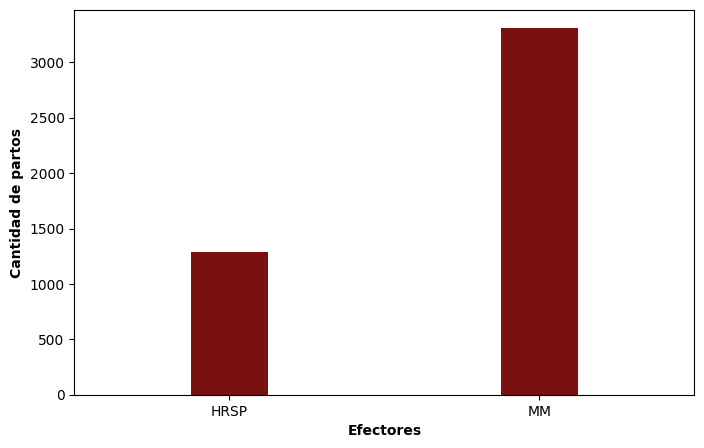

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize = (8,5))
sns.countplot(x = 'efector', width = 0.25, color = 'darkred', data = df)
plt.xlabel('Efectores', fontweight = 'bold')
plt.ylabel('Cantidad de partos', fontweight = 'bold')
plt.show()

Claramente, la Maternidad Martin (MM) atendió la mayor cantidad de partos en el año 2022 con más del doble de partos que HRSP.

# Item 3

Realice un gráfico que permita comparar la distribución del peso de los recién nacidos entre las distintas categorías de la edad gestacional. ¿Qué observa?

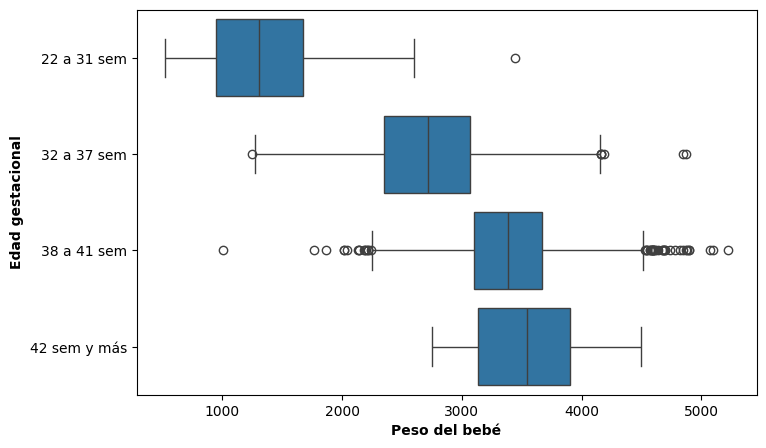

In [37]:
orden = (df.groupby('edad_gestacional')['peso_bb']
            .median()
            .sort_values()
            .index)

plt.figure(figsize = (8, 5))

sns.boxplot(x = 'peso_bb', y = 'edad_gestacional',
                order = orden, data = df)
plt.xlabel('Peso del bebé', fontweight = 'bold')
plt.ylabel('Edad gestacional', fontweight = 'bold')
plt.show()

Observamos que a mayor edad hay mayor peso.

# Item 4

Realice una descripción general de las variables rango etario de la madre (`rango_edad_mama`) y tipo de parto (`terminacion_parto`) que incluya: tipo de variables, valores que toman, distribución de cada una en la muestra y presencia de datos faltantes.

In [68]:
# Análisis de la variable 'rango_edad_mama'

print('Variable categórica')
print('Toma los valores:\n', df['rango_edad_mama'].unique(),'\n')
print('Distribución')
df["rango_edad_mama"].value_counts(dropna=False)

# Observamos la presencia de valores nulos.



Variable categórica
Toma los valores:
 <StringArray>
[ '35 a 39 años',  '25 a 29 años',  '20 a 24 años',  '30 a 34 años',
  '15 a 19 años',             nan,  '40 a 44 años',  '10 a 14 años',
  '45 a 49 años', '50 años y más']
Length: 10, dtype: str 

Distribución


rango_edad_mama
20 a 24 años     1345
25 a 29 años     1232
30 a 34 años      888
15 a 19 años      560
35 a 39 años      424
40 a 44 años      117
NaN                20
10 a 14 años        7
45 a 49 años        3
50 años y más       1
Name: count, dtype: int64

In [70]:
# Análisis de la variable 'terminacion_parto'

print('Variable cuantitativa discreta')
print('Toma los valores:\n', df['terminacion_parto'].unique(),'\n')
print('Distribución')
df["terminacion_parto"].value_counts(dropna=False)


Variable cuantitativa discreta
Toma los valores:
 <StringArray>
['Cesárea', 'Normal', 'Fórceps', 'Otros']
Length: 4, dtype: str 

Distribución


terminacion_parto
Normal     3169
Cesárea    1364
Fórceps      54
Otros        10
Name: count, dtype: int64

## Item 5

Recategorice la variable `rango_edad_mama` de la siguiente manera: 10-19 años, 20-29 años, 30-39 años y 40 años o más.

In [82]:
# Definimos la siguiente función que permite recategorizar en los intervalos dados

def recod_edad(x:str) -> str:
    '''
    Recategoriza las edades.
    '''
    if pd.isna(x):
        return None
    
    digito = int(x[0]) # Miramos el primer dígito de la edad menor del intervalo
    
    if digito < 2:
        return '10-19 años'
    elif digito == 2:
        return '20-29 años'
    elif digito == 3:
        return '30-39 años'
    else:
        return '40 años o más'

# Recategorizamos en una nueva variable.
df["edad_rec"] = df["rango_edad_mama"].apply(recod_edad)

df.head()

,año,mes,efector,idParto,idMama,rango_edad_mama,n_hijo,lugar_parto,terminacion_parto,edad_gestacional,peso_bb,sexo,nacimiento,edad_rec,parto_rec
0,2022,8,HRSP,1,951,35 a 39 años,1,Quirófano,Cesárea,32 a 37 sem,2980,M,Vivo,30-39 años,Cesárea
1,2022,1,HRSP,2,3437,25 a 29 años,1,Quirófano,Cesárea,38 a 41 sem,4215,F,Vivo,20-29 años,Cesárea
2,2022,1,HRSP,3,3411,20 a 24 años,1,Sala de partos,Normal,38 a 41 sem,3920,M,Vivo,20-29 años,Normal
3,2022,1,HRSP,4,528,25 a 29 años,1,Sala de partos,Normal,38 a 41 sem,3950,M,Vivo,20-29 años,Normal
4,2022,1,HRSP,5,2030,30 a 34 años,1,Sala de partos,Normal,38 a 41 sem,2650,M,Vivo,30-39 años,Normal


# Item 6

Recategorice la variable `terminacion_parto` de forma tal que la categoría Fórceps se encuentre comprendida dentro de Otros.

In [83]:
# Definimos una función que recategorice lo pedido
def recod_parto(x):
    if x == "Fórceps":
        return "Otros"
    else:
        return x

# Guaramos esta recategorización en otra variable
df["parto_rec"] = df["terminacion_parto"].apply(recod_parto)

df["parto_rec"].unique()

<StringArray>
['Cesárea', 'Normal', 'Otros']
Length: 3, dtype: str

## Item 7

Construya un gráfico de barras paralelas que muestre la distribución general del tipo de parto (Cesárea/Normal/Otros) según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados sobre el total general de partos atendidos para los que se cuenta con información sobre la edad de la madre (`n = 4577`).

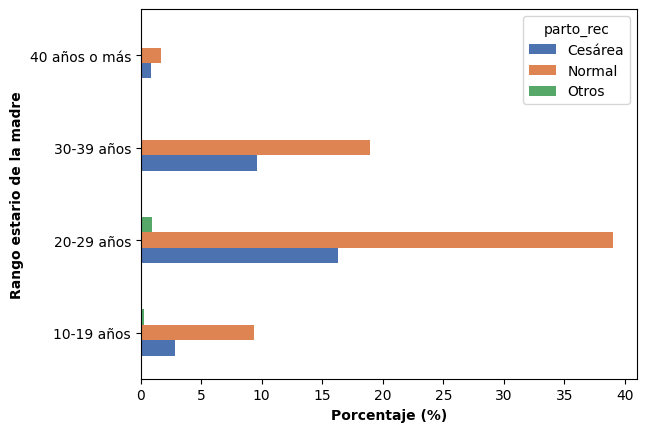

In [98]:
tabla = pd.crosstab(df["edad_rec"], df["parto_rec"])

tabla_total = tabla / tabla.values.sum() * 100

tabla_total.plot.barh()
plt.xlabel('Porcentaje (%)', fontweight = 'bold')
plt.ylabel('Rango estario de la madre', fontweight = 'bold')
plt.show()

## Item 8

Construya un gráfico de barras paralelas que muestre la distribución del tipo de parto según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados sobre el total de partos atendidos para cada uno de estos grupos etarios.

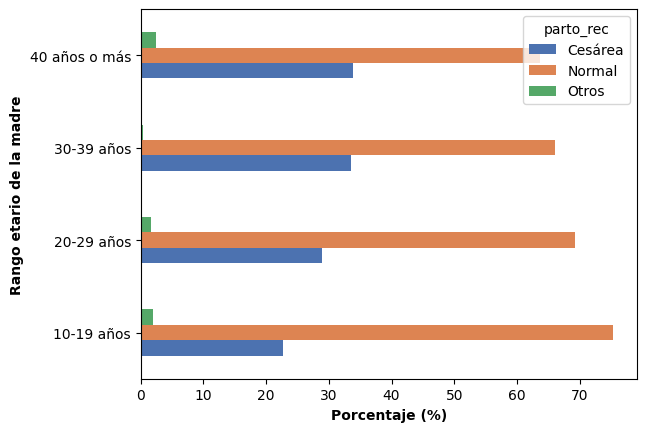

In [99]:
tabla_grupo = tabla.div(tabla.sum(axis=1), axis=0) * 100

tabla_grupo.plot.barh()
plt.xlabel('Porcentaje (%)', fontweight = 'bold')
plt.ylabel('Rango etario de la madre', fontweight = 'bold')
plt.show()

## Item 9

Compare los gráficos realizados en el ítem anterior. ¿Qué tipo de información brinda cada uno?

Gráfico 7 (sobre total):
- Muestra el peso relativo de cada grupo en el total.
- Mezcla tamaño del grupo + comportamiento.

Gráfico 8 (por grupo):
- Muestra proporciones internas.
- Permite comparar comportamientos entre edades.

## Item 10

PARA PENSAR: ¿Cuál de los gráficos anteriores le permite analizar si la edad de la madre influye en la probabilidad de recurrir a una cesárea como método de parto? ¿Qué observa?

El gráfico del ítem 8 permite analizar esta cuestión ya que permite ver dentro de cada edad el porcentaje de madres que deberien recurrir a una cesárea. Esto permite determinar directamente la probalidad según edad.

En este caso observamos que mientras más edad tiene la persona, más probable es que tenga que recurrir a una cesárea. Esto es una asociación y no causalidad ya que puede haber factores clínicos detrás de estos valores.